# Fake News Detection System Using a Bidirectional LSTM and a Fine‑Tuned RoBERTa Transformer: An End‑to‑End Natural Language Processing Pipeline for Reliable News Classification

### Importing Necessary Libraries

This code block imports essential libraries for data analysis, visualization, and machine learning:

*   **pandas (pd):** Used for data manipulation and analysis, particularly with DataFrames.
*   **numpy (np):** Provides numerical computing tools, including arrays and mathematical functions.
*   **matplotlib.pyplot (plt):** Enables creating static, interactive, and animated visualizations.
*   **seaborn (sns):** Builds on matplotlib to provide a high-level interface for statistical graphics.
*   **train_test_split (from sklearn.model_selection):** Splits data into training and testing sets for model evaluation.
*   **accuracy_score, confusion_matrix, classification_report, roc_curve, auc (from sklearn.metrics):** Provides various metrics to evaluate the performance of classification models.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc


In [5]:
!pip install wordcloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 547.9/547.9 kB 8.2 MB/s eta 0:00:00


In [ ]:
pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.9/644.9 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 75.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 109.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 97.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 108.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 6.6 MB/s eta 0:00:00


In [6]:
pip install tf-keras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 17.1 MB/s eta 0:00:00


In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
from collections import Counter
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from transformers import BertTokenizer, TFBertForSequenceClassification
from transformers import RobertaTokenizer, TFRobertaForSequenceClassification
from transformers import InputExample, InputFeatures


/usr/local/lib/python3.11/dist-packages/torch_xla/__init__.py:251: UserWarning: `tensorflow` can conflict with `torch-xla`. Prefer `tensorflow-cpu` when using PyTorch/XLA. To silence this warning, `pip uninstall -y tensorflow && pip install tensorflow-cpu`. If you are in a notebook environment such as Colab or Kaggle, restart your notebook runtime afterwards.
  warnings.warn(


### Downloading NLTK Resources

This code block downloads necessary resources for Natural Language Processing (NLP) tasks using the NLTK library:

*   **stopwords:** Downloads a list of common words (like "the", "a", "is") that are often removed from text during preprocessing.
*   **wordnet:** Downloads a lexical database for the English language that provides definitions, synonyms, and other semantic relationships between words.
*   **omw-1.4:** Downloads the Open Multilingual Wordnet, which is a multilingual lexical database. This is likely used for lemmatization with WordNetLemmatizer.

In [7]:
# Download NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')


NameError: name 'nltk' is not defined

### Loading Datasets

This code block loads two CSV files into pandas DataFrames:

*   **`fake_df = pd.read_csv('Fake.csv', encoding='ISO-8859-1', quotechar='"', on_bad_lines='skip')`**: Reads the 'Fake.csv' file, which presumably contains fake news articles. `encoding='ISO-8859-1'` is specified to handle potential encoding issues. `quotechar='"'` indicates that double quotes are used as quote characters in the CSV file.  `on_bad_lines='skip'` means that if there is a parsing issue, those rows should be skipped.
*   **`true_df = pd.read_csv('True.csv', encoding='ISO-8859-1', quotechar='"', on_bad_lines='skip')`**: Reads the 'True.csv' file, which presumably contains real news articles. Same CSV reading parameter configuration as above.

In [ ]:
fake_df = pd.read_csv('Fake.csv', encoding='ISO-8859-1', quotechar='"', on_bad_lines='skip')
true_df = pd.read_csv('True.csv', encoding='ISO-8859-1', quotechar='"', on_bad_lines='skip')


### Labeling and Combining Datasets

This code block performs two crucial steps:

1.  **Adding Labels:**
    *   `fake_df['label'] = 1`:  A new column named 'label' is added to the `fake_df` DataFrame, and all rows are assigned the value 1, indicating fake news.
    *   `true_df['label'] = 0`: Similarly, a 'label' column is added to `true_df`, with all rows assigned 0, representing true news.

2.  **Combining and Shuffling:**
    *   `df = pd.concat([fake_df, true_df], axis=0)`: The `fake_df` and `true_df` DataFrames are combined vertically (along rows - `axis=0`) into a single DataFrame named `df`.
    *   `df = df.sample(frac=1).reset_index(drop=True)`: The combined dataset `df` is shuffled randomly using `sample(frac=1)` (which samples 100% of the data) and the index is reset using `reset_index(drop=True)`. This ensures the data is in a random order for training machine learning models.

In [ ]:
# Add labels
fake_df['label'] = 1  # 1 for fake news
true_df['label'] = 0  # 0 for true news

# Combine datasets
df = pd.concat([fake_df, true_df], axis=0)
df = df.sample(frac=1).reset_index(drop=True)  # Shuffle the dataset

### Basic Data Exploration

This code block performs initial data exploration:

*   **`print(df.info())`:** Prints a concise summary of the DataFrame `df`, including the data types of each column and the number of non-null values. This provides a quick overview of the dataset's structure.
*   **`print(df['label'].value_counts())`:** Prints the frequency of each unique value in the 'label' column. This helps understand the distribution of fake (1) and true (0) news articles in the dataset.

In [ ]:
# Basic exploration
print(df.info())
print(df['label'].value_counts())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44897 entries, 0 to 44896
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44897 non-null  object
 1   text     44897 non-null  object
 2   subject  44897 non-null  object
 3   date     44897 non-null  object
 4   label    44897 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.7+ MB
None
label
1    23481
0    21416
Name: count, dtype: int64


In [ ]:

# Check for missing values
print(df.isnull().sum())



title      0
text       0
subject    0
date       0
label      0
dtype: int64


In [ ]:

# Text preprocessing function
def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # Remove user @ references and '#' from tweet
    text = re.sub(r'\@\w+|\#', '', text)

    # Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)

    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    words = text.split()
    words = [word for word in words if word not in stop_words]

    # Lemmatization
    lemmatizer = WordNetLemmatizer()
    words = [lemmatizer.lemmatize(word) for word in words]

    return ' '.join(words)

# Apply preprocessing
df['processed_text'] = df['text'].apply(preprocess_text)


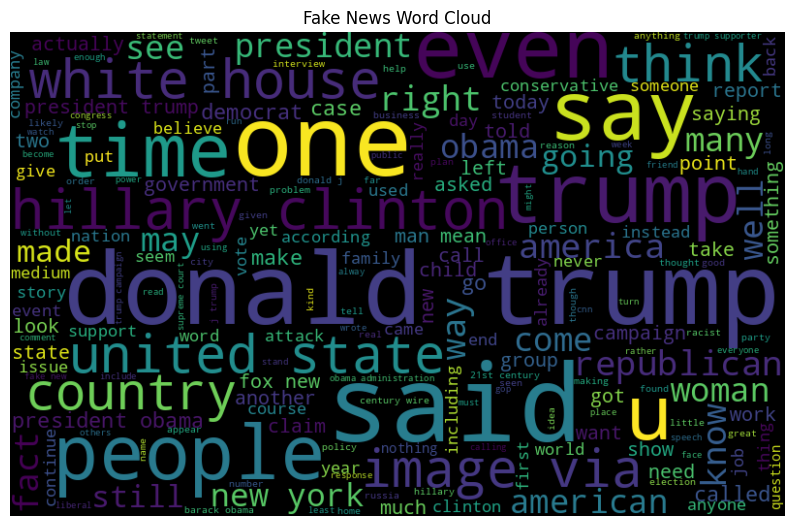

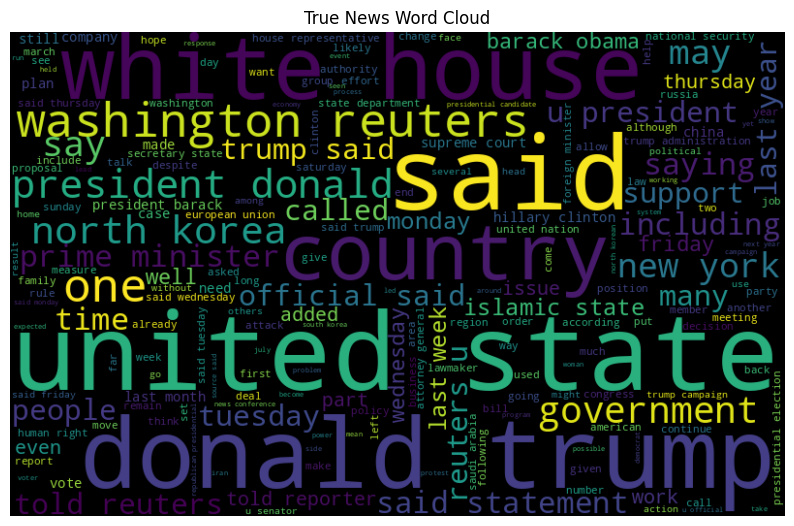

In [ ]:
# Visualize word clouds
def plot_wordcloud(text, title):
    wordcloud = WordCloud(width=800, height=500,
                          random_state=21, max_font_size=110).generate(text)
    plt.figure(figsize=(10, 7))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis('off')
    plt.title(title)
    plt.show()

# Word cloud for fake news
fake_text = " ".join(text for text in df[df['label']==1]['processed_text'])
plot_wordcloud(fake_text, "Fake News Word Cloud")

# Word cloud for true news
true_text = " ".join(text for text in df[df['label']==0]['processed_text'])
plot_wordcloud(true_text, "True News Word Cloud")

In [ ]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    df['processed_text'], df['label'], test_size=0.2, random_state=42
)

# For LSTM model
max_words = 10000
max_len = 200

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)

# Convert text to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Pad sequences
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)





### Building and Summarizing the LSTM Model

This code block defines and initializes an LSTM model for fake news detection:

1. **`def build_lstm_model():`**: This function defines the architecture of the LSTM model.
    * `model = Sequential()`: Creates a sequential model, where layers are added in order.
    * `model.add(Embedding(...))`: Creates an embedding layer to represent words as vectors.
    * `model.add(Bidirectional(LSTM(...)))`: Adds bidirectional LSTM layers for capturing sequential information.
    * `model.add(Dense(...))`: Adds dense layers for classification.
    * `model.add(Dropout(...))`: Applies dropout to prevent overfitting.
    * `model.compile(...)`: Compiles the model with an optimizer, loss function, and metrics.
2. **`lstm_model = build_lstm_model()`**: Creates an instance of the LSTM model.
3. **`lstm_model.

In [ ]:
def build_lstm_model():
    model = Sequential()
    model.add(Embedding(input_dim=max_words, output_dim=128, input_length=max_len))
    model.add(Bidirectional(LSTM(64, return_sequences=True)))
    model.add(Bidirectional(LSTM(32)))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

lstm_model = build_lstm_model()
# After creating the model but before summary
lstm_model.build(input_shape=(None, max_len))  # None for batch dimension
# Create dummy data with correct shape
dummy_input = tf.random.uniform((1, max_len), minval=0, maxval=max_words, dtype=tf.int32)
_ = lstm_model(dummy_input)  # This builds the model
lstm_model.summary()  # Now shows proper shapes

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 200, 128)            │       1,280,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, 200, 128)            │          98,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ (None, 64)                  │          41,216 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,424,257 (5.43 MB)

 Trainable params: 1,424,257 (5.43 MB)

 Non-trainable params: 0 (0.00 B)

# Train LSTM model

In [ ]:

# Train LSTM model
history = lstm_model.fit(
    X_train_pad, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)



Epoch 1/5
506/506 ━━━━━━━━━━━━━━━━━━━━ 241s 467ms/step - accuracy: 0.8937 - loss: 0.2311 - val_accuracy: 0.9713 - val_loss: 0.0898
Epoch 2/5
506/506 ━━━━━━━━━━━━━━━━━━━━ 234s 463ms/step - accuracy: 0.9882 - loss: 0.0416 - val_accuracy: 0.9891 - val_loss: 0.0404
Epoch 3/5
506/506 ━━━━━━━━━━━━━━━━━━━━ 235s 464ms/step - accuracy: 0.9962 - loss: 0.0140 - val_accuracy: 0.9858 - val_loss: 0.0467
Epoch 4/5
506/506 ━━━━━━━━━━━━━━━━━━━━ 234s 463ms/step - accuracy: 0.9958 - loss: 0.0140 - val_accuracy: 0.9897 - val_loss: 0.0419
Epoch 5/5
506/506 ━━━━━━━━━━━━━━━━━━━━ 234s 463ms/step - accuracy: 0.9984 - loss: 0.0057 - val_accuracy: 0.9875 - val_loss: 0.0511


In [ ]:
lstm_model.save("lstm_model.keras")


# Plot training history

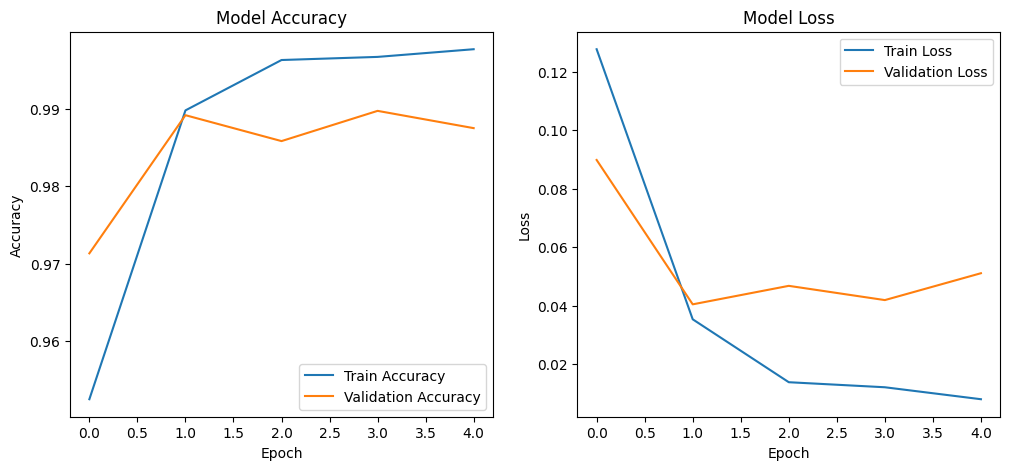

In [ ]:
# Plot training history
def plot_history(history):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

plot_history(history)


# Evaluate LSTM model

281/281 ━━━━━━━━━━━━━━━━━━━━ 18s 61ms/step
LSTM Model Evaluation:
Accuracy: 0.988641425389755

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4273
           1       0.99      0.99      0.99      4707

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



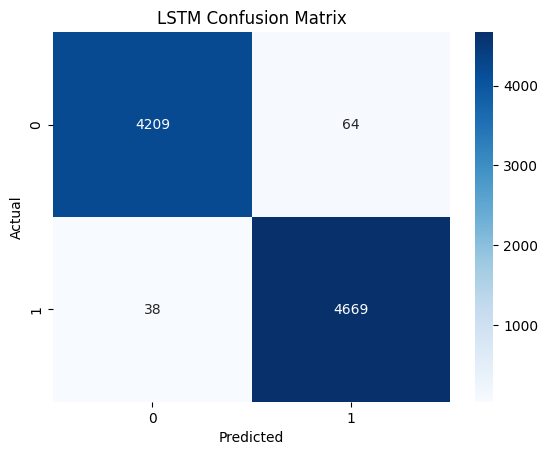

In [ ]:

# Evaluate LSTM model
y_pred_lstm = (lstm_model.predict(X_test_pad) > 0.5).astype("int32")

print("LSTM Model Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred_lstm))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lstm))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_lstm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('LSTM Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
from tensorflow.keras.models import load_model

loaded_model = load_model("lstm_model.keras")


# BERT

In [8]:

import pandas as pd
import numpy as np
import tensorflow as tf
from transformers import TFBertForSequenceClassification, BertTokenizer
from transformers.optimization_tf import AdamWeightDecay
from sklearn.model_selection import train_test_split

# Load data
fake_df = pd.read_csv('Fake.csv', encoding='ISO-8859-1', quotechar='"', on_bad_lines='skip')
true_df = pd.read_csv('True.csv', encoding='ISO-8859-1', quotechar='"', on_bad_lines='skip')

# Label the data
fake_df['label'] = 0
true_df['label'] = 1

# Combine datasets
df = pd.concat([fake_df, true_df], ignore_index=True)
df = df.sample(frac=1).reset_index(drop=True)  # Shuffle the data

# Use the text content (you can choose 'title' or 'text' or combine both)
df['text'] = df['title'] + " " + df['text']

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(df['text'], df['label'], test_size=0.2, stratify=df['label'])

/usr/local/lib/python3.11/dist-packages/torch_xla/__init__.py:251: UserWarning: `tensorflow` can conflict with `torch-xla`. Prefer `tensorflow-cpu` when using PyTorch/XLA. To silence this warning, `pip uninstall -y tensorflow && pip install tensorflow-cpu`. If you are in a notebook environment such as Colab or Kaggle, restart your notebook runtime afterwards.
  warnings.warn(


### Preparing Data for BERT

This code block defines helper classes and functions to prepare the data for BERT:

1. **`InputExample` and `InputFeatures` classes:**
    * These classes are used to structure the input data for BERT. `InputExample` holds the raw text and label, while `InputFeatures` holds the tokenized input IDs, attention mask, and label.

2. **Loading the Tokenizer:**
    * `tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')`: Loads the pre-trained BERT tokenizer from the 'bert-base-uncased' model. This tokenizer is used to convert text into numerical input IDs that BERT can understand.

3. **Data Conversion Functions:**
    * `convert_example_to_feature`: Converts a text and label pair into an `InputExample` object.
    * `convert_examples_to_tf_dataset`: Converts a list of `InputExample` objects into a `tf.data.Dataset` that can be used for training and evaluation. It tokenizes the text, creates attention masks, and formats the data into the required structure.

4. **Preparing Input Examples:**
    * `train_examples` and `test_examples`: Lists of `InputExample` objects are created for the training and test data.

### Fine-tuning BERT for Fake News Detection

This code block focuses on fine-tuning a pre-trained BERT model for the fake news classification task:

1. **Loading the Pre-trained Model:**
    * `model = TFBertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)`: Loads the 'bert-base-uncased' model, which is pre-trained on a large text corpus. `num_labels=2` specifies that we have two classes (fake and true).

2. **Creating the Optimizer:**
    * `optimizer = AdamWeightDecay(learning_rate=3e-5, weight_decay_rate=0.01)`: Creates an Adam optimizer with weight decay, commonly used for fine-tuning BERT.

3. **Compiling the Model:**
    * `model.compile(...)`: Configures the model for training by specifying the optimizer, loss function (`SparseCategoricalCrossentropy`),

In [26]:


# Define helper classes
class InputExample:
    def __init__(self, guid, text_a, label):
        self.guid = guid
        self.text_a = text_a
        self.label = label

class InputFeatures:
    def __init__(self, input_ids, attention_mask, label):
        self.input_ids = input_ids
        self.attention_mask = attention_mask
        self.label = label

# Load tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Convert to InputExample format
def convert_example_to_feature(text, label):
    return InputExample(guid=None, text_a=text, label=label)

# Convert InputExamples to tf.data.Dataset
def convert_examples_to_tf_dataset(examples, tokenizer, max_length=128):
    features = []
    for example in examples:
        inputs = tokenizer.encode_plus(
            example.text_a,
            add_special_tokens=True,
            max_length=max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_token_type_ids=False,
            return_tensors="tf"
        )
        features.append(InputFeatures(
            input_ids=inputs['input_ids'][0],
            attention_mask=inputs['attention_mask'][0],
            label=example.label
        ))

    def gen():
        for f in features:
            yield {"input_ids": f.input_ids, "attention_mask": f.attention_mask}, f.label

    return tf.data.Dataset.from_generator(
        gen,
        output_signature=(
            {
                "input_ids": tf.TensorSpec(shape=(None,), dtype=tf.int32),
                "attention_mask": tf.TensorSpec(shape=(None,), dtype=tf.int32)
            },
            tf.TensorSpec(shape=(), dtype=tf.int64)
        )
    )

# Prepare InputExamples
train_examples = [convert_example_to_feature(text, label) for text, label in zip(X_train, y_train)]
test_examples = [convert_example_to_feature(text, label) for text, label in zip(X_test, y_test)]

# Create datasets
train_dataset = convert_examples_to_tf_dataset(train_examples, tokenizer).shuffle(100).batch(16)
test_dataset = convert_examples_to_tf_dataset(test_examples, tokenizer).batch(16)

# Load pre-trained BERT model for sequence classification
model = TFBertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)

# Create optimizer
optimizer = AdamWeightDecay(learning_rate=3e-5, weight_decay_rate=0.01)

# Compile model
model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

# Train model
model.fit(train_dataset, epochs=1)

# Evaluate model
loss, accuracy = model.evaluate(test_dataset)
print(f"Test Accuracy: {accuracy:.4f}")


All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


562/562 [==============================] - 444s 782ms/step - loss: 0.0037 - accuracy: 0.9990
Test Accuracy: 0.9990


# Save the model and tokenizer

In [27]:
# Save the model and tokenizer
model.save_pretrained("bert_fake_news_model")
tokenizer.save_pretrained("bert_fake_news_model")

print("Model and tokenizer saved to 'bert_fake_news_model/' directory")


Model and tokenizer saved to 'bert_fake_news_model/' directory


In [28]:
from transformers import TFBertForSequenceClassification, BertTokenizer

# Load from the saved folder
model = TFBertForSequenceClassification.from_pretrained("bert_fake_news_model")
tokenizer = BertTokenizer.from_pretrained("bert_fake_news_model")


Some layers from the model checkpoint at bert_fake_news_model were not used when initializing TFBertForSequenceClassification: ['dropout_189']
- This IS expected if you are initializing TFBertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
All the layers of TFBertForSequenceClassification were initialized from the model checkpoint at bert_fake_news_model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertForSequenceClassification for predictions without further training.


In [29]:
import tensorflow as tf
import numpy as np

def predict_fake_news(text):
    # Tokenize the input text
    inputs = tokenizer.encode_plus(
        text,
        add_special_tokens=True,
        max_length=128,
        truncation=True,
        padding='max_length',
        return_attention_mask=True,
        return_token_type_ids=False,
        return_tensors="tf"
    )

    # Run through the model
    outputs = model(inputs)
    logits = outputs.logits
    predicted_class = tf.argmax(logits, axis=1).numpy()[0]

    # Map class to label
    label_map = {0: "Fake", 1: "True"}
    return label_map[predicted_class]


In [30]:
text = "The president declared a nationwide lockdown effective immediately."
result = predict_fake_news(text)

print(f"Prediction: {result}")


Prediction: Fake


In [31]:
import shutil

# Zip the folder
shutil.make_archive('bert_fake_news_model', 'zip', 'bert_fake_news_model')

# Download it
from google.colab import files
files.download('bert_fake_news_model.zip')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Fine-tuning RoBERTa for Fake News Detection

This code block focuses on fine-tuning a pre-trained RoBERTa model for fake news classification:

1. **Model Initialization:**
    * `model = TFRobertaForSequenceClassification.from_pretrained('roberta-base', num_labels=2)`: Loads the pre-trained RoBERTa model for sequence classification, specifying two output labels (fake and true).
    * `optimizer = AdamWeightDecay(...)`: Creates an Adam optimizer with weight decay for training.
    * `model.compile(...)`: Compiles the model, configuring the optimizer, loss function, and evaluation metrics.

2. **Training:**
    * `history = model.fit(...)`: Trains the model using the training dataset (`train_dataset`), validating its performance on the test dataset (`test_dataset`) for two epochs. Class weights (`class_weight_dict`) are applied to handle potential class imbalance.

3. **Evaluation:**
    * `y_pred_logits = model.predict(...)`: Obtains predictions from the model on the test dataset.
    * `y_pred = tf.argmax(...)`: Converts the predicted logits into class labels (0 for fake, 1 for true).
    * `print(classification_report(...))`: Prints a classification report, providing precision, recall, F1-score, and support for each class.

4. **Saving the Model:**
    * `model.save_pretrained(...)`: Saves the fine-tuned RoBERTa model to the specified directory.
    * `tokenizer.save_pretrained(...)`: Saves the RoBERTa tokenizer to the same directory.

In [43]:
# Step 1: Install required libraries
!pip install transformers

# Step 2: Imports
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from sklearn.metrics import classification_report

from transformers import RobertaTokenizer, TFRobertaForSequenceClassification
from transformers.optimization_tf import AdamWeightDecay

# Step 3: Load and Label Data
fake_df = pd.read_csv('Fake.csv', encoding='ISO-8859-1', quotechar='"', on_bad_lines='skip')
true_df = pd.read_csv('True.csv', encoding='ISO-8859-1', quotechar='"', on_bad_lines='skip')

fake_df['label'] = 0
true_df['label'] = 1

df = pd.concat([fake_df, true_df], ignore_index=True)
df = df.sample(frac=1).reset_index(drop=True)  # Shuffle

# Combine title and text for classification input
df['text'] = df['title'] + " " + df['text']

X = df['text'].values
y = df['label'].values

# Step 4: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

# Step 5: Tokenizer and Dataset Creation
tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

def encode(texts, labels, tokenizer, max_len=128):
    input_ids, attention_masks = [], []
    for text in texts:
        encoded = tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True
        )
        input_ids.append(encoded['input_ids'])
        attention_masks.append(encoded['attention_mask'])
    return {
        "input_ids": tf.constant(input_ids),
        "attention_mask": tf.constant(attention_masks)
    }, tf.constant(labels)

train_dataset = tf.data.Dataset.from_tensor_slices(encode(X_train, y_train, tokenizer)).shuffle(100).batch(16)
test_dataset = tf.data.Dataset.from_tensor_slices(encode(X_test, y_test, tokenizer)).batch(16)

# Step 6: Compute Class Weights
class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))
print("Class Weights:", class_weight_dict)

# Step 7: Model Initialization
model = TFRobertaForSequenceClassification.from_pretrained('roberta-base', num_labels=2)

optimizer = AdamWeightDecay(learning_rate=3e-5, weight_decay_rate=0.01)

model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

# Step 8: Training
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=2,
    class_weight=class_weight_dict
)

# Step 9: Evaluation
y_pred_logits = model.predict(test_dataset).logits
y_pred = tf.argmax(y_pred_logits, axis=1).numpy()

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Fake", "True"]))

# Step 10: Save model and tokenizer
model.save_pretrained("roberta_fake_news_model")
tokenizer.save_pretrained("roberta_fake_news_model")
print("✅ RoBERTa model saved to 'roberta_fake_news_model/'")


Class Weights: {0: np.float64(0.9560530238500852), 1: np.float64(1.0481818712426312)}


Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFRobertaForSequenceClassification: ['roberta.embeddings.position_ids']
- This IS expected if you are initializing TFRobertaForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFRobertaForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFRobertaForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.dense.weight', 'classifier.dense.bias', 'classifier.out_proj.weight', 'classifier.out_proj.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predicti

Epoch 1/2
2245/2245 [==============================] - 5873s 3s/step - loss: 0.0079 - accuracy: 0.9970 - val_loss: 0.0032 - val_accuracy: 0.9997
Epoch 2/2
562/562 [==============================] - 447s 782ms/step

Classification Report:

              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00      4697
        True       1.00      1.00      1.00      4283

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980

✅ RoBERTa model saved to 'roberta_fake_news_model/'


In [44]:
import shutil
from google.colab import files

# Zip it
shutil.make_archive('roberta_fake_news_model', 'zip', 'roberta_fake_news_model')

# Download
files.download('roberta_fake_news_model.zip')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [45]:

# Evaluate RoBERTa model
roberta_predictions = model.predict(test_dataset)
roberta_preds = tf.argmax(roberta_predictions.logits, axis=1)

print("\nRoBERTa Model Evaluation:")
print("Accuracy:", accuracy_score(y_test, roberta_preds))
print("\nClassification Report:")
print(classification_report(y_test, roberta_preds))


562/562 [==============================] - 441s 784ms/step

RoBERTa Model Evaluation:
Accuracy: 0.9996659242761693

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4697
           1       1.00      1.00      1.00      4283

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



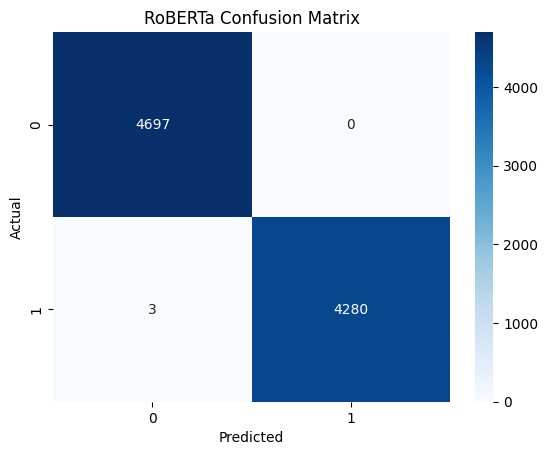

In [46]:

# Confusion matrix
cm = confusion_matrix(y_test, roberta_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('RoBERTa Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()